# Procesado de los datos y entrenamiento del modelo



In [31]:
import subprocess
import importlib
libraries = ['shap','lime','ucimlrepo']
for lib in libraries:
    spec = importlib.util.find_spec(lib)
    if spec is None:
        # If the library isn't installed, install it
        print(f"{lib} is not installed. Installing...")
        subprocess.check_call(["pip", "install", lib])
        print(f"{lib} has been installed.\n")
    else:
        print(f"{lib} is installed.")

shap is installed.
lime is installed.
ucimlrepo is installed.


In [32]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from contextlib import redirect_stdout

import shap
import lime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [33]:
# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# In the dataframe y (labels) there are these unique values: ['<=50K' '>50K' '<=50K.' '>50K.']
# We are going to delate the dot (.)
y['income'] = y['income'].str.replace('.', '')

features_encoder = OrdinalEncoder()
label_encoder = LabelEncoder()
X_columns = X.columns
y_columns = y.columns

X = features_encoder.fit_transform(X)
X = pd.DataFrame(X, columns=X_columns)

y = label_encoder.fit_transform(y)
y = pd.DataFrame(y, columns=y_columns)

The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


In [34]:
knn_imputer = ColumnTransformer([('Inputer knn', KNNImputer(n_neighbors=5, weights="distance"), ['workclass', 'occupation', 'native-country'])],
                                remainder='passthrough', verbose_feature_names_out=False, n_jobs=-1)
knn_imputer.set_output(transform='pandas')
X = knn_imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [35]:
clf = GradientBoostingClassifier (n_estimators =100, random_state =10)
clf.fit (X_train.values, y_train)

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


GradientBoostingClassifier(random_state=10)

# Actividades

## A)  Primero, prepara las explicaciones que evaluaremos con las métricas. Para ello usa las técnicas de SHAP y LIME ya conocidas y obtén una lista de características importantes. Haz un Plot de los resultados para ambos casos.  

  0%|          | 0/200 [00:00<?, ?it/s]

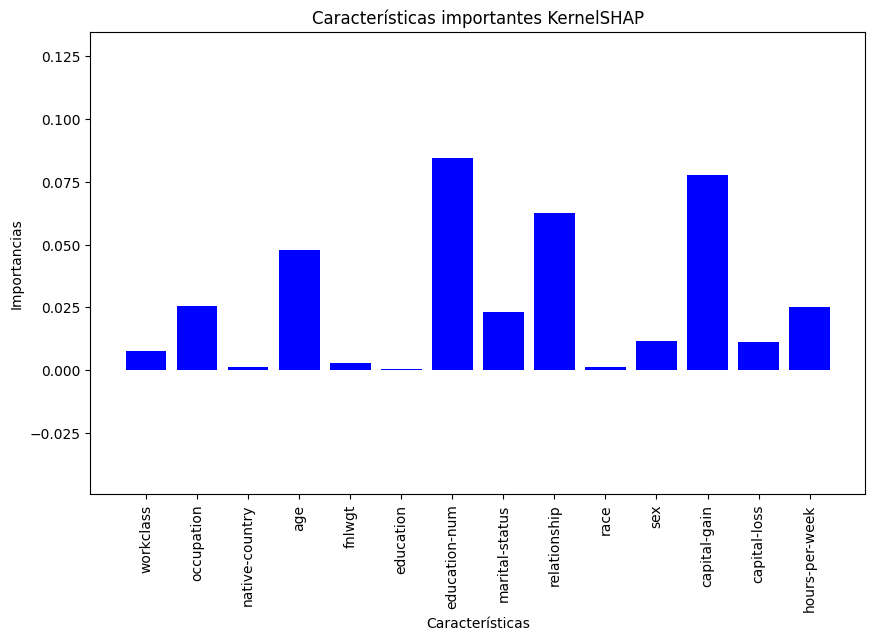

[('education-num', 0.08445126099928332), ('capital-gain', 0.07757654647286437), ('relationship', 0.06273563482001267), ('age', 0.04768923809553598), ('occupation', 0.025635072694298867), ('hours-per-week', 0.02511749724052804), ('marital-status', 0.0231296537852062), ('sex', 0.011691777635451348), ('capital-loss', 0.011073080971880374), ('workclass', 0.007779895387890313), ('fnlwgt', 0.0027168977337568407), ('native-country', 0.0011757241483960346), ('race', 0.0011202396354902694), ('education', 0.0006319890990421991)]


In [36]:
#SHAP
explainer_kernel = shap.KernelExplainer(clf.predict, shap.sample(X_train, 50))
explicaciones_shap = explainer_kernel.shap_values(X_test[0:200])

#shap.summary_plot(explicaciones_shap, X_test[0:200])
plt.figure(figsize=(10, 6))
plt.bar(X_test.columns, np.abs(explicaciones_shap).mean(axis=0), color='blue')
plt.xlabel('Características')
plt.ylabel('Importancias')
plt.title('Características importantes KernelSHAP')
plt.tick_params(axis='x', rotation=90, labelsize=10)
plt.ylim(min(np.abs(explicaciones_shap).mean(axis=0))-0.05, max(np.abs(explicaciones_shap).mean(axis=0))+0.05)
plt.show()

caracteristicas_shap = list(zip(X_test.columns,np.abs(explicaciones_shap).mean(axis=0)))
caracteristicas_ordenadas_shap = sorted(caracteristicas_shap, key = lambda x: x[1], reverse = True)
print(caracteristicas_ordenadas_shap)


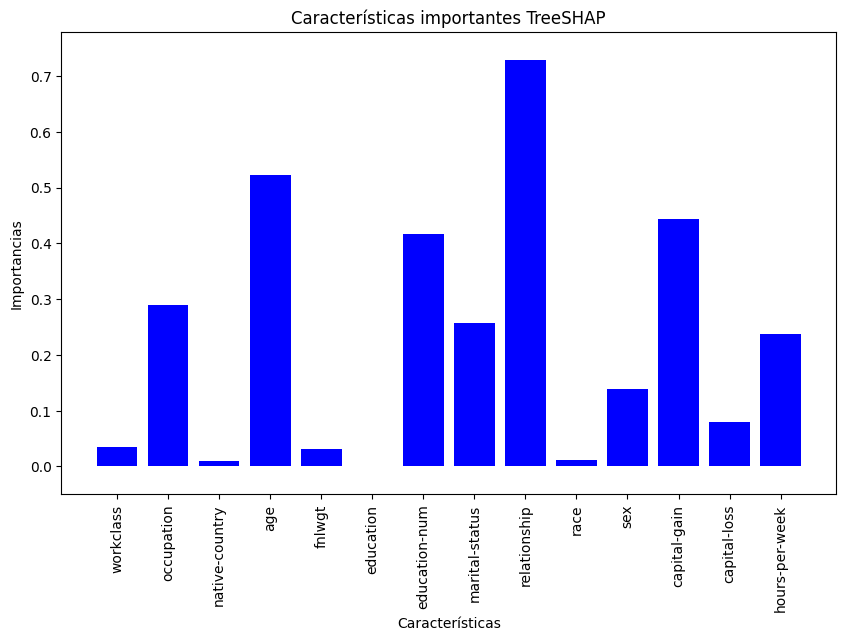

[('relationship', 0.7281168900288632), ('age', 0.5223519843301029), ('capital-gain', 0.4440205096551294), ('education-num', 0.41673303227428077), ('occupation', 0.29029368205727635), ('marital-status', 0.25645916614767306), ('hours-per-week', 0.23684399948373602), ('sex', 0.1392400373475698), ('capital-loss', 0.07913530018076032), ('workclass', 0.034764105767012256), ('fnlwgt', 0.03106859312866927), ('race', 0.012263994310456116), ('native-country', 0.009735754511030653), ('education', 0.0)]


In [37]:
#SHAP
explainer_tree = shap.TreeExplainer(clf)
explicaciones_shap_tree = explainer_tree.shap_values(X_test[0:200])

#shap.summary_plot(explicaciones_shap, X_test[0:200])
plt.figure(figsize=(10, 6))
plt.bar(X_test.columns, np.abs(explicaciones_shap_tree).mean(axis=0), color='blue')
plt.xlabel('Características')
plt.ylabel('Importancias')
plt.title('Características importantes TreeSHAP')
plt.tick_params(axis='x', rotation=90, labelsize=10)
plt.ylim(min(np.abs(explicaciones_shap_tree).mean(axis=0))-0.05, max(np.abs(explicaciones_shap_tree).mean(axis=0))+0.05)
plt.show()

caracteristicas_shap_tree = list(zip(X_test.columns,np.abs(explicaciones_shap_tree).mean(axis=0)))
caracteristicas_ordenadas_shap_tree = sorted(caracteristicas_shap_tree, key = lambda x: x[1], reverse = True)
print(caracteristicas_ordenadas_shap_tree)


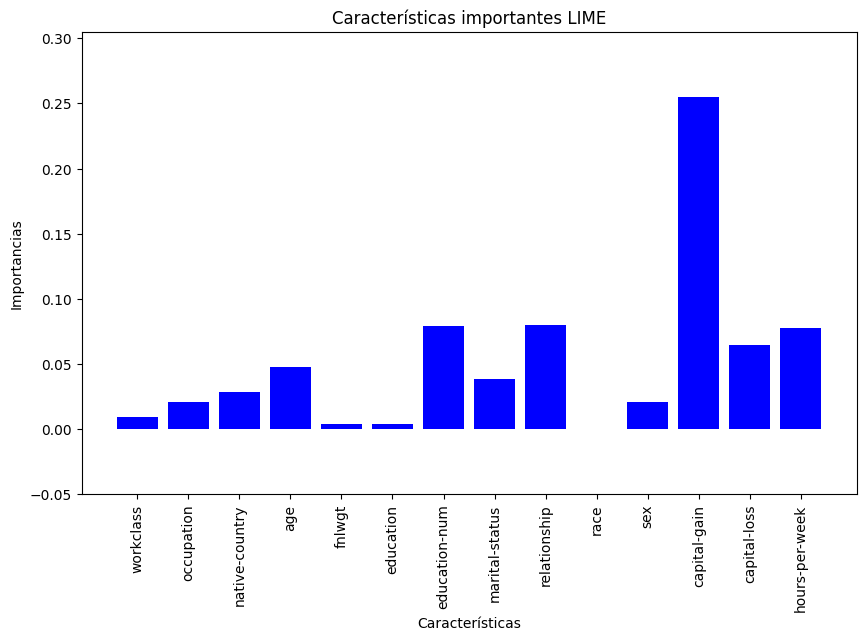

[('capital-gain', 0.25455784071046894), ('relationship', 0.08009715121053439), ('education-num', 0.0789803826733699), ('hours-per-week', 0.07751627359419744), ('capital-loss', 0.06471220395640072), ('age', 0.04785018537545059), ('marital-status', 0.038224686922411294), ('native-country', 0.028446297912722587), ('occupation', 0.021157815288327074), ('sex', 0.020904663407573625), ('workclass', 0.009703844173140167), ('education', 0.003924843686193488), ('fnlwgt', 0.0036826304033008243), ('race', 0.0)]


In [38]:
# LIME
explainer_lime = lime.lime_tabular.LimeTabularExplainer(X_train.values)
attributions_lime = []
exp_size = X_test[0:200].shape[0]
for i in range(exp_size):
  attribution_lime = explainer_lime.explain_instance(X_test[0:200].values[i], clf.predict_proba, num_features=len(X_test.columns))
  attributions_lime.append(attribution_lime.local_exp[1])

npattrib = np.array(attributions_lime)

att_lime_summary = []
for at in attributions_lime:
  sorted_data = sorted(at, key=lambda x: x[0])
  att_lime_summary.append([x[1] for x in sorted_data])

explicaciones_lime = np.array(att_lime_summary)

#shap.summary_plot(explicaciones_lime, X_test[0:200])

plt.figure(figsize=(10, 6))
plt.bar(X_test.columns, np.abs(explicaciones_lime).mean(axis=0), color='blue')
plt.xlabel('Características')
plt.ylabel('Importancias')
plt.title('Características importantes LIME')
plt.tick_params(axis='x', rotation=90, labelsize=10)
plt.ylim(min(np.abs(explicaciones_lime).mean(axis=0))-0.05, max(np.abs(explicaciones_lime).mean(axis=0))+0.05)
plt.show()

caracteristicas_lime = list(zip(X_test.columns,np.abs(explicaciones_lime).mean(axis=0)))
caracteristicas_ordenadas_lime = sorted(caracteristicas_lime, key = lambda x: x[1], reverse = True)
print(caracteristicas_ordenadas_lime)

## B)  Escribe una función para generar un vector de precisión de la predicción a medida que se insertan características en orden de mayor a menor importancia (Inserción). Dibuja los valores obtenidos de precisión para cada caso y calcula el área bajo la curva para ambos métodos.

In [39]:
def metrica_insercion(lista_pares_caracteristicas, modelo, X_test, y_test):

    vector_precision = list()
    lista_caracteristicas, _= zip(*lista_pares_caracteristicas)
    aux = list()
    vector_auc = list()
    for caract in lista_caracteristicas:

        aux.append(caract)
        X_test_aux = X_test.copy()

        for col in X_test_aux.columns:
            if col not in aux:
                 # No se si utilizar la media o el cero
                X_test_aux[col] = 0

        predicciones_reducidas = modelo.predict(X_test_aux)

        precision_reducida = accuracy_score(y_test, predicciones_reducidas)

        vector_precision.append( precision_reducida)


        auc = roc_auc_score(y_test, predicciones_reducidas)
        vector_auc.append(auc)

    return vector_precision, vector_auc

vector_precision_shap_kernel, vector_auc_shap_kernel = metrica_insercion(caracteristicas_ordenadas_shap, clf, X_test, y_test)
vector_precision_shap_tree, vector_auc_shap_tree = metrica_insercion(caracteristicas_ordenadas_shap_tree, clf, X_test, y_test)
vector_precision_lime, vector_auc_lime = metrica_insercion(caracteristicas_ordenadas_lime, clf, X_test, y_test)

X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted wi

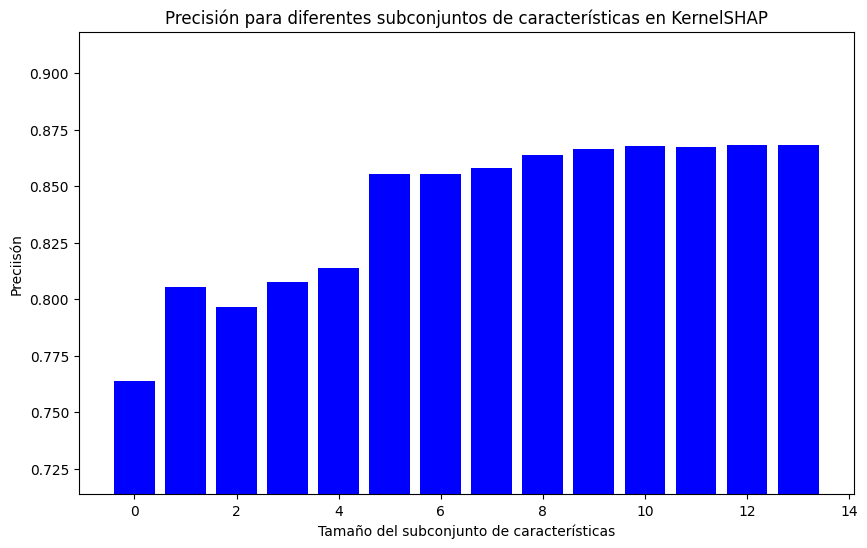

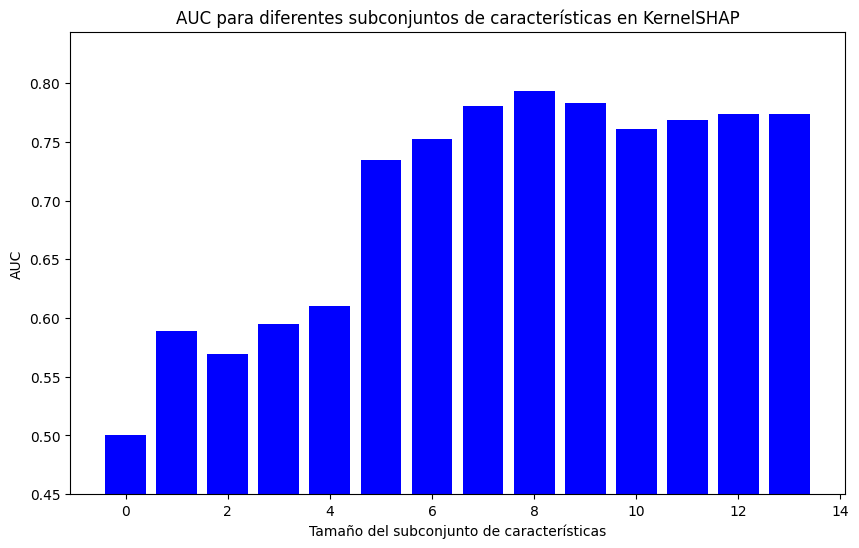

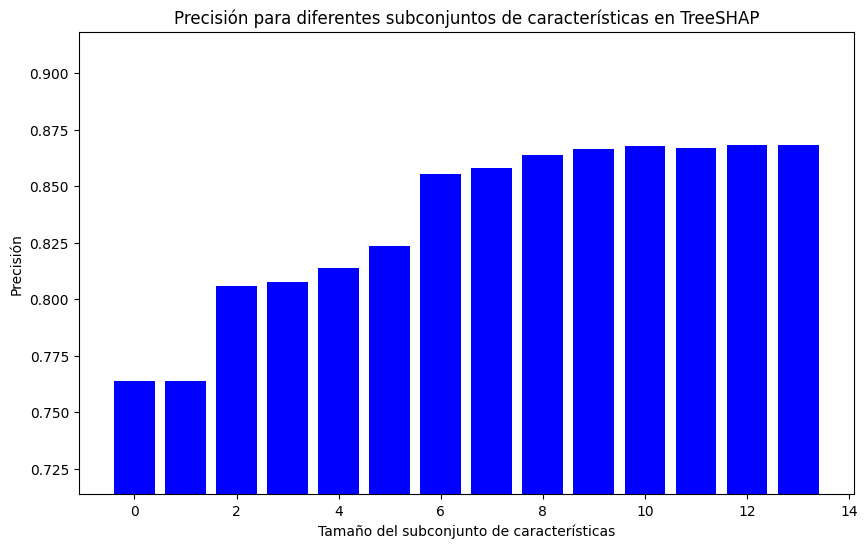

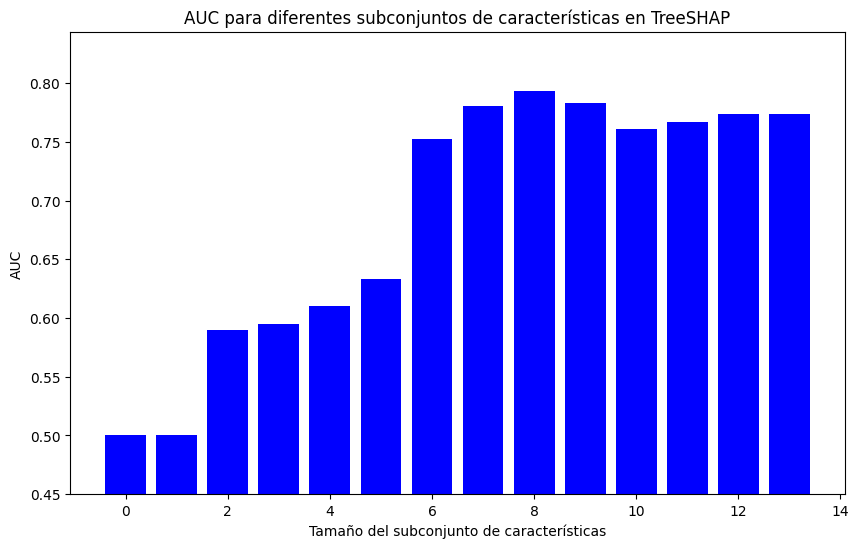

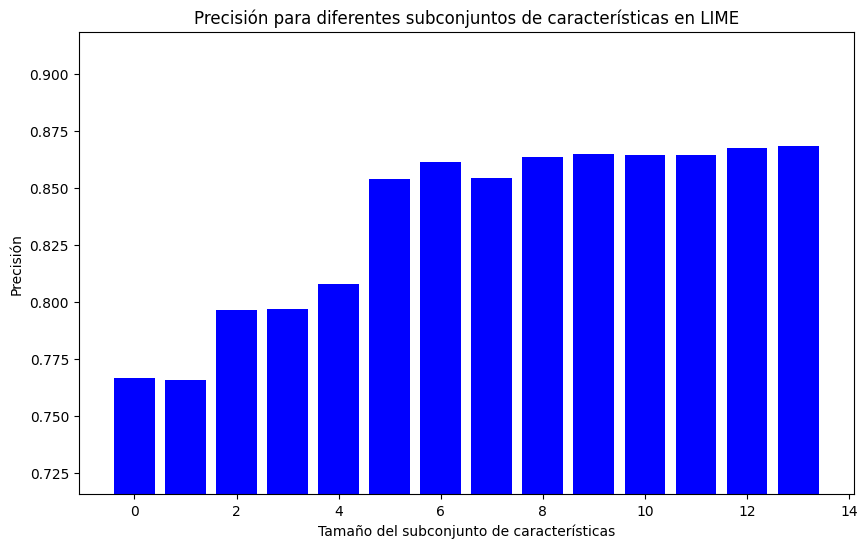

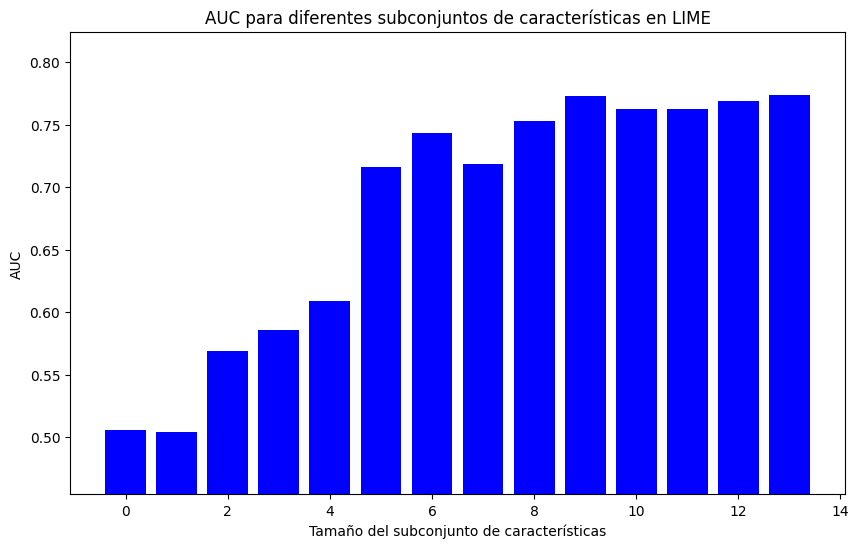

In [43]:
# KernelSHAP

plt.figure(figsize=(10, 6))
plt.bar(range(len(vector_precision_shap_kernel)), vector_precision_shap_kernel, color='blue')
plt.xlabel('Tamaño del subconjunto de características')
plt.ylabel('Preciisón')
plt.title('Precisión para diferentes subconjuntos de características en KernelSHAP')
plt.ylim(min(vector_precision_shap_kernel)-0.05, max(vector_precision_shap_kernel)+0.05)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(range(len(vector_auc_shap_kernel)), vector_auc_shap_kernel, color='blue')
plt.xlabel('Tamaño del subconjunto de características')
plt.ylabel('AUC')
plt.title('AUC para diferentes subconjuntos de características en KernelSHAP')
plt.ylim(min(vector_auc_shap_kernel)-0.05, max(vector_auc_shap_kernel)+0.05)
plt.show()

# TreeSHAP

plt.figure(figsize=(10, 6))
plt.bar(range(len(vector_precision_shap_tree)), vector_precision_shap_tree, color='blue')
plt.xlabel('Tamaño del subconjunto de características')
plt.ylabel('Precisión')
plt.title('Precisión para diferentes subconjuntos de características en TreeSHAP')
plt.ylim(min(vector_precision_shap_tree)-0.05, max(vector_precision_shap_tree)+0.05)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(range(len(vector_auc_shap_tree)), vector_auc_shap_tree, color='blue')
plt.xlabel('Tamaño del subconjunto de características')
plt.ylabel('AUC')
plt.title('AUC para diferentes subconjuntos de características en TreeSHAP')
plt.ylim(min(vector_auc_shap_tree)-0.05, max(vector_auc_shap_tree)+0.05)
plt.show()

# LIME

plt.figure(figsize=(10, 6))
plt.bar(range(len(vector_precision_lime)), vector_precision_lime, color='blue')
plt.xlabel('Tamaño del subconjunto de características')
plt.ylabel('Precisión')

plt.title('Precisión para diferentes subconjuntos de características en LIME')
plt.ylim(min(vector_precision_lime)-0.05, max(vector_precision_lime)+0.05)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(range(len(vector_auc_lime)), vector_auc_lime, color='blue')
plt.xlabel('Tamaño del subconjunto de características')
plt.ylabel('AUC')
plt.title('AUC para diferentes subconjuntos de características en LIME')
plt.ylim(min(vector_auc_lime)-0.05, max(vector_auc_lime)+0.05)
plt.show()

## C)  Compara los métodos con una línea base. Puedes realizar una selección aleatoria de las características como línea base para realizar la comparación. ¿Qué método funciona mejor? ¿Puedes establecer una medida cuantitativa y/o cualitativa?


X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted without feature names
X has feature names, but GradientBoostingClassifier was fitted wi

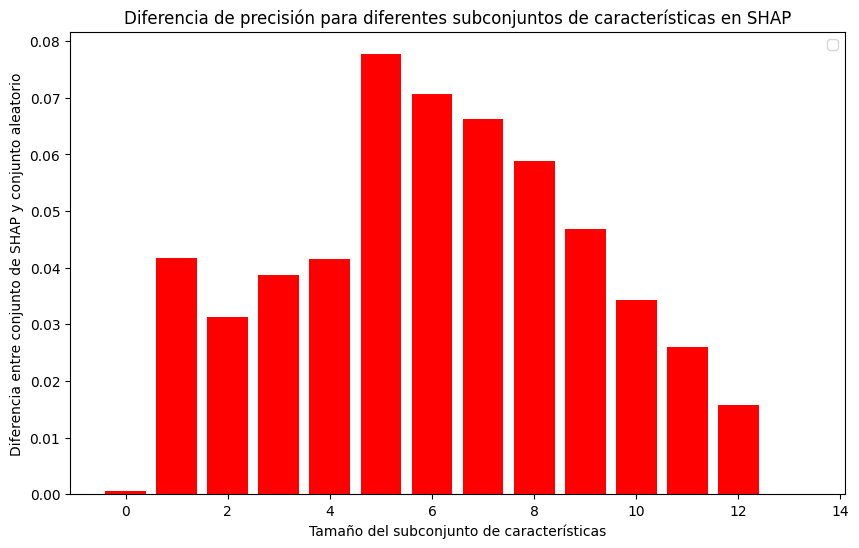

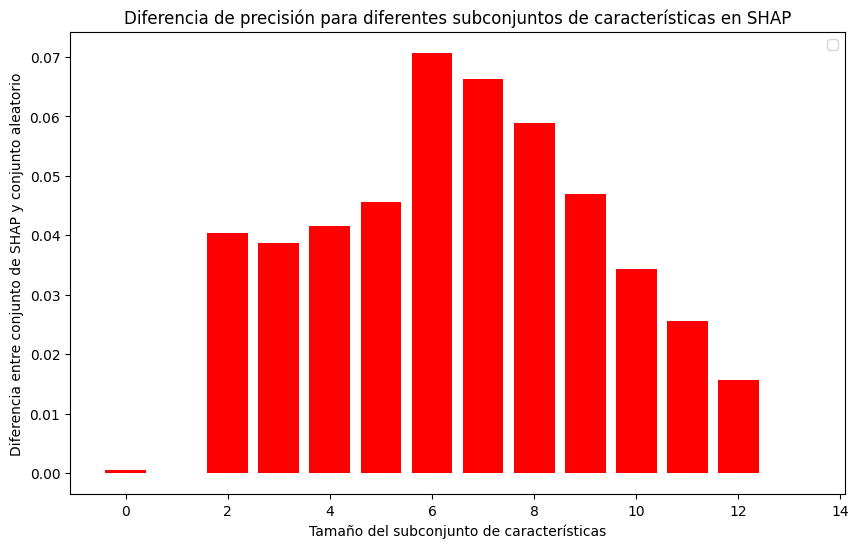

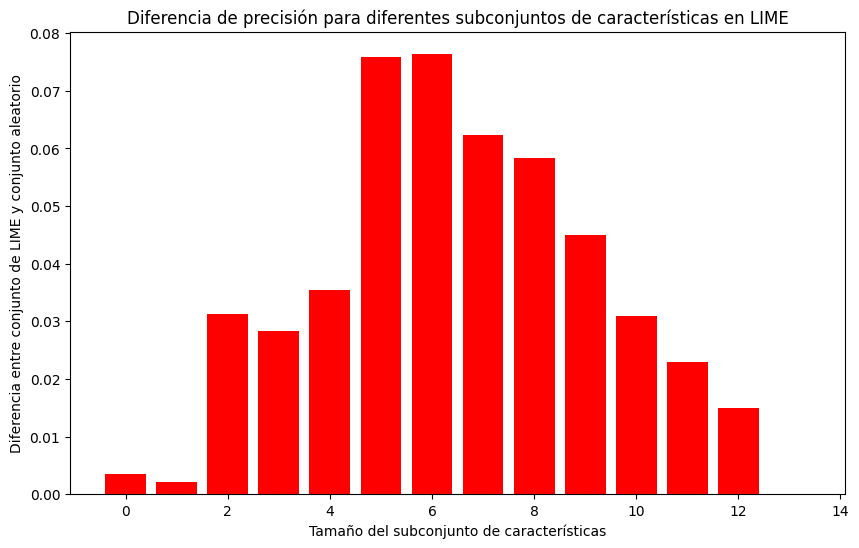

Puntuación KernelSHAP: 0.03928703040229294
Puntuación TreeSHAP: 0.034636751824283794
Puntuación LIME: 0.03482685755231563


In [45]:
vector_medias_diferencia_shap_kernel = list()
vector_medias_diferencia_shap_tree = list()
vector_medias_diferencia_lime = list()

for i in range(100):
  caracteristicas_random, _= zip(*caracteristicas_ordenadas_shap)
  caracteristicas_random = list(caracteristicas_random)
  random.shuffle(caracteristicas_random)

  vector_precision_random = list()

  aux = list()
  vector_auc = list()
  for caract in caracteristicas_random:

      aux.append(caract)
      X_test_aux = X_test.copy()

      for col in X_test_aux.columns:
          if col not in aux:
                # No se si utilizar la media o el cero
              X_test_aux[col] = 0

      predicciones_reducidas = clf.predict(X_test_aux)

      precision_reducida = accuracy_score(y_test, predicciones_reducidas)

      vector_precision_random.append( precision_reducida)


      auc = roc_auc_score(y_test, predicciones_reducidas)
      vector_auc.append(auc)



  vector_diferencia_shap_kernel = np.array(vector_precision_shap_kernel) - np.array(vector_precision_random)
  vector_medias_diferencia_shap_kernel.append(vector_diferencia_shap_kernel)

  vector_diferencia_shap_tree = np.array(vector_precision_shap_tree) - np.array(vector_precision_random)
  vector_medias_diferencia_shap_tree.append(vector_diferencia_shap_tree)

  vector_diferencia_lime = np.array(vector_precision_lime) - np.array(vector_precision_random)
  vector_medias_diferencia_lime.append(vector_diferencia_lime)


vector_medias_diferencia_shap_kernel = np.array(vector_medias_diferencia_shap_kernel)

vector_medias_diferencia_shap_tree = np.array(vector_medias_diferencia_shap_tree)
vector_medias_diferencia_lime = np.array(vector_medias_diferencia_lime)

vector_final_diferencias_shap_kernel = np.mean(vector_medias_diferencia_shap_kernel, axis=0)
vector_final_diferencias_shap_tree = np.mean(vector_medias_diferencia_shap_tree, axis=0)
vector_final_diferencias_lime = np.mean(vector_medias_diferencia_lime, axis=0)

#print(vector_final_diferencias_shap)

# KernelSHAP

plt.figure(figsize=(10, 6))
plt.bar(range(len(vector_final_diferencias_shap_kernel)), vector_final_diferencias_shap_kernel, color='red')
plt.xlabel('Tamaño del subconjunto de características')
plt.ylabel('Diferencia entre conjunto de SHAP y conjunto aleatorio')
plt.title('Diferencia de precisión para diferentes subconjuntos de características en SHAP')
#plt.ylim(min(vector_final_diferencias_shap_kernel)-0.05, max(vector_final_diferencias_shap_kernel)+0.05)
plt.legend()
plt.show()

# TreeSHAP

plt.figure(figsize=(10, 6))
plt.bar(range(len(vector_final_diferencias_shap_tree)), vector_final_diferencias_shap_tree, color='red')
plt.xlabel('Tamaño del subconjunto de características')
plt.ylabel('Diferencia entre conjunto de SHAP y conjunto aleatorio')
plt.title('Diferencia de precisión para diferentes subconjuntos de características en SHAP')
#plt.ylim(min(vector_final_diferencias_shap_tree)-0.05, max(vector_final_diferencias_shap_tree)+0.05)
plt.legend()
plt.show()



#vector_diferencia_lime = np.array(vector_precision_lime) - np.array(vector_precision_random)

# LIME

plt.figure(figsize=(10, 6))
plt.bar(range(len(vector_final_diferencias_lime)), vector_final_diferencias_lime, color='red')
plt.xlabel('Tamaño del subconjunto de características')
plt.ylabel('Diferencia entre conjunto de LIME y conjunto aleatorio')
plt.title('Diferencia de precisión para diferentes subconjuntos de características en LIME')
#plt.ylim(min(vector_final_diferencias_lime)-0.05, max(vector_final_diferencias_lime)+0.05)
plt.show()

puntuacion_shap_kernel = np.mean(vector_final_diferencias_shap_kernel)

puntuacion_shap_tree = np.mean(vector_final_diferencias_shap_tree)
puntuacion_lime = np.mean(vector_final_diferencias_lime)

print("Puntuación KernelSHAP: " + str(puntuacion_shap_kernel))

print("Puntuación TreeSHAP: " + str(puntuacion_shap_tree))
print("Puntuación LIME: " + str(puntuacion_lime))


# Es mejor el que tenga una diferencia mayor, ya que habrá ordenado mejor las características al tener
# más diferencia en precisión con la selección aleatoria. Se ha iterado varias veces para
# obtener la diferencia y hacer la media

# Cualitativamente no se como decir cual es mejor